#### Author's Information:
        Author : Ali Rizvi.
        Stu ID : 2410057
        Module : HEP502 of MSc Computer Sciences with Artificial Intelligence.
        Title  : Comparative Evaluation of MLP and CNN on Fashion-MNIST.
        Purpose: Final Assessment
---


| #| ## of Notebook | Title of Notebook |
|--|---|---|
| **1st** | **00** | **Data Loading and Sanity Checks** |
| 2| 01 | Baseline MLP |
| 3| 02 | Baseline CNN |
| 4| 03 | Regularisation Experiments |
| 5| 04 | Depth and Capacity Variance |
| 6| 05 | Robustness Testing |
| 7| 06 | Consolidated Analysis |


**This is Notebook 00,** 1st of this 7-notebook series. The following are the goals of this notebook:
## Goals:
1) Load Fashion-MNIST
2) Inspect shapes, dtypes, label meaning
3) Normalize images
4) Create train/validation split
5) Visualize samples and class distribution

**This notebook creates clean arrays used by later notebooks.**

#### Importing libraries

In [1]:
# Uncomment and run the command below, if tensorflow keras is not installed
# pip install tensorflow

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

#### Reproductibility 

In order to get similar results at each run, lets introduce seeds

In [3]:
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

### Loading the dataset

In [4]:
# Load the data
(x_train_data, y_train_data), (x_test_data, y_test_data) = keras.datasets.fashion_mnist.load_data()

In [5]:
# Checking shapes of datasets
splits = {"x_train shape": x_train_data, 
          "y_train shape": y_train_data, 
          "x_test shape": x_test_data, 
          "y_test shape": y_test_data}

for name, split in splits.items():
    print(f"{name}: {split.shape}")


x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [6]:
# Human-readable labels
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

Number of classes: 10


#### Safety Checks
To avoid silent errors and to follow some good practices

In [7]:
assert x_train_data.ndim == 3, "Expected (N, 28, 28)"
assert x_train_data.shape[1:] == (28, 28), "Expected 28x28 images"
assert y_train_data.min() >= 0 and y_train_data.max() < num_classes, "Labels out of range"

print(f"Pixel range: {x_train_data.min()} to {x_train_data.max()}")

Pixel range: 0 to 255


### Intial Explorations
#### Peeking into samples

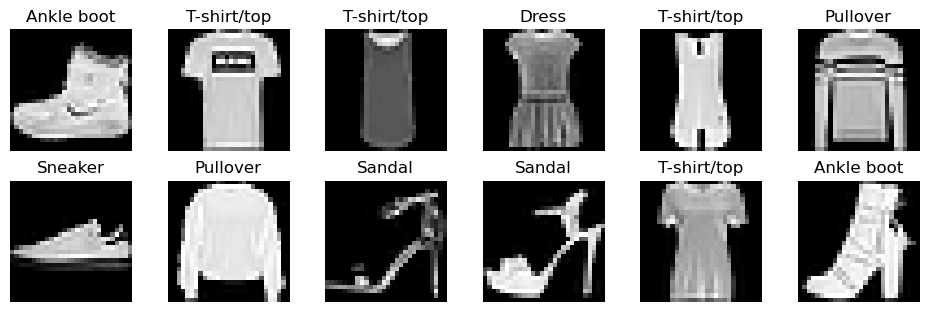

In [8]:
# Define the layout of the gallery (2 rows × 6 columns = 12 images total)
n_rows = 2
n_cols = 6

def show_image_grid(images, labels, class_names, n_rows, n_cols):
    # Scale figure size
    plt.figure(figsize=(n_cols * 1.6, n_rows * 1.6))
    
    # Loop through the required number of images
    for i in range(n_rows * n_cols):
        # Create subplot index
        ax = plt.subplot(n_rows, n_cols, i + 1)
        # Display image in grayscale
        ax.imshow(images[i], cmap="gray")
        # Use numeric labels
        ax.set_title(class_names[labels[i]])
        ax.axis("off")
    
    # Show the image
    plt.tight_layout()
    plt.show()

# Display a small sample from the training set
show_image_grid(x_train_data, y_train_data, class_names, n_rows, n_cols)

- In the sample above, labels match the visual category.
- However, some images are a little ambigous. It will be interesting to see how the model is going to handle these.

#### Normalizing images to `float32` datatype

In [9]:
train_images = x_train_data.astype("float32") / 255.0
test_images  = x_test_data.astype("float32") / 255.0

train_labels = y_train_data.copy()
test_labels  = y_test_data.copy()

In [10]:
print(f"Normalized pixel range: {train_images.min()} to {train_images.max()}")
print(f"Datatype: {train_images.dtype}")

Normalized pixel range: 0.0 to 1.0
Datatype: float32


### Validation Sets
Lets do a clean 80/20 split of the training set.

In [11]:
def train_val_split(images, labels, valid_frac, seed):
    rng = np.random.default_rng(seed) # Reporductible shuffling
    idx = np.arange(len(images))
    rng.shuffle(idx)

    # Determine # of samples into validation set
    valid_size = int(len(images) * valid_frac)
    valid_idx = idx[:valid_size]
    train_idx = idx[valid_size:]

    # Split using shuffled indices to avoid ordering bias
    x_train = images[train_idx]
    y_train = labels[train_idx]
    x_valid = images[valid_idx]
    y_valid = labels[valid_idx]

    return x_train, y_train, x_valid, y_valid

In [12]:
# Split the data
x_train, y_train, x_val, y_val = train_val_split(train_images, train_labels, valid_frac=0.2, seed=SEED)

In [14]:
# Checking shapes of datasets
print(f"x_train:{x_train.shape}, y_train: {y_train.shape}")
print(f"x_val:{x_val.shape}, y_val: {y_val.shape}")
print(f"x_test:{x_test_data.shape}, y_test: {y_test_data.shape}")

x_train:(48000, 28, 28), y_train: (48000,)
x_val:(12000, 28, 28), y_val: (12000,)
x_test:(10000, 28, 28), y_test: (10000,)


#### Class Distribution Checks

In [16]:
def plot_class_counts(labels, class_names, title):
    # count occurrences of each class (ensures all classes appear via minlength)
    counts = np.bincount(labels, minlength=len(class_names))
    plt.figure(figsize=(10, 3))
    plt.bar(np.arange(len(class_names)), counts)
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()

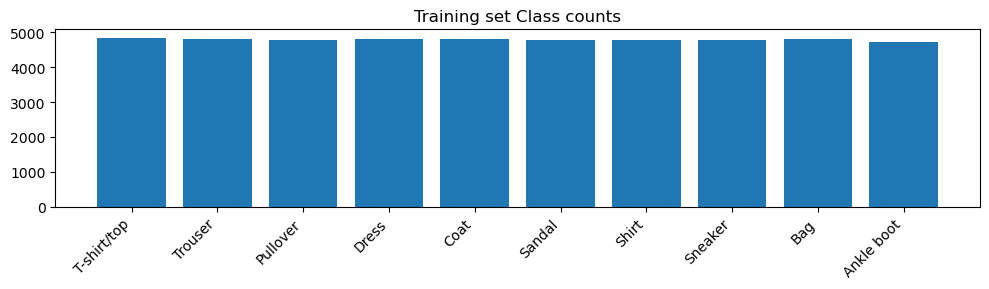

In [17]:
plot_class_counts(y_train, class_names, "Training set Class counts")

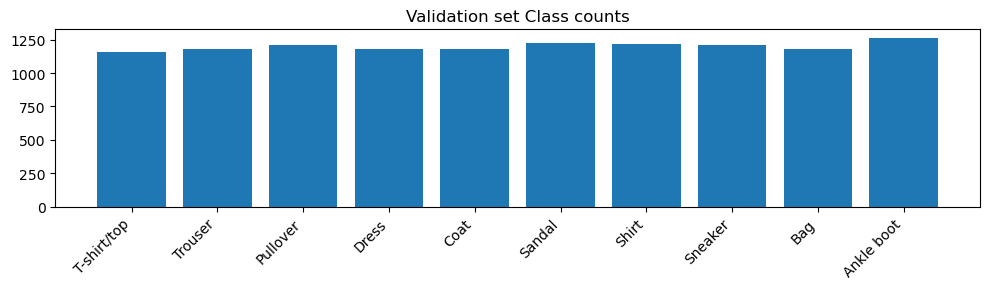

In [18]:
plot_class_counts(y_val, class_names, "Validation set Class counts")

### Saving the prepared arrays

In [31]:
print(f"Current working directory: {os.getcwd()}")
print(f"Contents of CWD: {os.listdir()}")

Current working directory: C:\Users\ALI\PG\HEP502_work\alirizvi_2410057_hep502\code_mlp_vs_cnn
Contents of CWD: ['.ipynb_checkpoints', '00 Data loading + sanity checks.ipynb', 'anaconda_projects', 'outputs']


In [32]:
# Save all processed splits into a single compressed file for reuse
np.savez_compressed(
    "outputs/fashion_mnist_prepared_00.npz",
    x_train=x_train, y_train=y_train, 
    x_val=x_val, y_val=y_val, 
    x_test=test_images, y_test=test_labels
)

print(f"Files successfully saved")

Files successfully saved
